# import library

In [1]:
import numpy as np
import pandas as pd
import collections
from mpl_toolkits.mplot3d import Axes3D
from IPython import display
from matplotlib import pyplot as plt
import sklearn
import sklearn.manifold
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)
import altair as alt

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
alt.data_transformers.enable('default', max_rows=None)
alt.renderers.enable('colab')

RendererRegistry.enable('colab')

# unduh dataset

In [3]:
print("Downloading movielens data...")
from urllib.request import urlretrieve
import zipfile

urlretrieve("http://files.grouplens.org/datasets/movielens/ml-100k.zip", "movielens.zip")
zip_ref = zipfile.ZipFile('movielens.zip', "r")
zip_ref.extractall()
print("Done. Dataset contains:")
print(zip_ref.read('ml-100k/u.info'))

Done. Dataset contains:
b'943 users\n1682 items\n100000 ratings\n'


In [6]:
# Load masing masing dataset (users, movies, and ratings).
users_cols = ['user_id', 'age', 'sex', 'occupation', 'zip_code']
users = pd.read_csv(
  'ml-100k/u.user', sep='|', names=users_cols, encoding='latin-1')

ratings_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings = pd.read_csv(
  'ml-100k/u.data', sep='\t', names=ratings_cols, encoding='latin-1')
# Genre pada setiap film bersifat biner.
genre_cols = [
  "genre_unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
  "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
  "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]
movies_cols = [
  'movie_id', 'title', 'release_date', "video_release_date", "imdb_url"
] + genre_cols
movies = pd.read_csv(
  'ml-100k/u.item', sep='|', names=movies_cols, encoding='latin-1')


In [7]:
print('Jumlah data film: ', len(movies.movie_id.unique()))
print('Jumlah data pengunjung: ', len(users.user_id.unique()))
print('Jumlah data penayangan: ', len(ratings.user_id))

Jumlah data film:  1682
Jumlah data pengunjung:  943
Jumlah data penayangan:  100000


menyelaraskan data dan memisahkan tahun rilis

In [8]:
users["user_id"] = users["user_id"].apply(lambda x: str(x-1))
movies["movie_id"] = movies["movie_id"].apply(lambda x: str(x-1))
movies["year"] = movies['release_date'].apply(lambda x: str(x).split('-')[-1])
ratings["movie_id"] = ratings["movie_id"].apply(lambda x: str(x-1))
ratings["user_id"] = ratings["user_id"].apply(lambda x: str(x-1))
ratings["rating"] = ratings["rating"].apply(lambda x: float(x))

In [10]:
genre_occurences = movies[genre_cols].sum().to_dict()
genre_occurences

{'genre_unknown': 2,
 'Action': 251,
 'Adventure': 135,
 'Animation': 42,
 'Children': 122,
 'Comedy': 505,
 'Crime': 109,
 'Documentary': 50,
 'Drama': 725,
 'Fantasy': 22,
 'Film-Noir': 24,
 'Horror': 92,
 'Musical': 56,
 'Mystery': 61,
 'Romance': 247,
 'Sci-Fi': 101,
 'Thriller': 251,
 'War': 71,
 'Western': 27}

menggabungkan genre menjadi satu buah string agar mudah melakukan proses embeddings

In [11]:
def mark_genres(movies, genres):
 def get_random_genre(gs):
  active = [genre for genre, g in zip(genres, gs) if g==1]
  if len(active) == 0:
   return 'Other'
  return np.random.choice(active)
 def get_all_genres(gs):
  active = [genre for genre, g in zip(genres, gs) if g==1]
  if len(active) == 0:
   return 'Other'
  return '-'.join(active)
 movies['genre'] = [
   get_random_genre(gs) for gs in zip(*[movies[genre] for genre in genres])]
 movies['all_genres'] = [
   get_all_genres(gs) for gs in zip(*[movies[genre] for genre in genres])]

mark_genres(movies, genre_cols)

merging

In [12]:
movielens = ratings.merge(movies, on='movie_id').merge(users, on='user_id')

# Display data

- pd.options.display.max_rows dan pd.options.display.float_format: untuk mengatur tampilan default saat kita mencetak atau menampilkan DataFrame menggunakan library pandas.
- Mask: untuk memfilter DataFrame berdasarkan kriteria yang diberikan pada kolom tertentu.
Flatten_cols: untuk menggabungkan multi-indeks kolom pada DataFrame menjadi satu level sehingga mempermudah manipulasi dan analisis data.

In [13]:
pd.options.display.max_rows = 10
pd.options.display.float_format = '{:.3f}'.format
def mask(df, key, function):
 """Returns a filtered dataframe, by applying function to key"""
 return df[function(df[key])]

def flatten_cols(df):
 df.columns = [' '.join(col).strip() for col in df.columns.values]
 return df

pd.DataFrame.mask = mask
pd.DataFrame.flatten_cols = flatten_cols

In [14]:
users.describe(include="all")

,user_id,age,sex,occupation,zip_code
count,943,943.000,943,943,943
unique,943,NaN,2,21,795
top,942,NaN,M,student,55414
freq,1,NaN,670,196,9
mean,NaN,34.052,NaN,NaN,NaN
...,...,...,...,...,...
min,NaN,7.000,NaN,NaN,NaN
25%,NaN,25.000,NaN,NaN,NaN
50%,NaN,31.000,NaN,NaN,NaN
75%,NaN,43.000,NaN,NaN,NaN


In [15]:
# Membuat filter untuk melakukan slicing data.
occupation_filter = alt.selection_multi(fields=["occupation"])
occupation_chart = alt.Chart().mark_bar().encode(
  x="count()",
  y=alt.Y("occupation:N"),
  color=alt.condition(
    occupation_filter,
    alt.Color("occupation:N", scale=alt.Scale(scheme='category20')),
    alt.value("lightgray")),
).properties(width=300, height=300, selection=occupation_filter)

# Fungsi yang dapat membuat histogram dari data yang sudah difilter.
def filtered_hist(field, label, filter):
 base = alt.Chart().mark_bar().encode(
   x=alt.X(field, bin=alt.Bin(maxbins=10), title=label),
   y="count()",
 ).properties(
   width=300,
 )
 return alt.layer(
   base.transform_filter(filter),
   base.encode(color=alt.value('lightgray'), opacity=alt.value(.7)),
 ).resolve_scale(y='independent')

/tmp/ipykernel_374/1329168637.py:2: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  occupation_filter = alt.selection_multi(fields=["occupation"])


visualisasi dataset rating

In [17]:
occupation_filter = alt.selection_multi(fields=["occupation"])
occupation_chart = alt.Chart().mark_bar().encode(
  x="count()",
  y=alt.Y("occupation:N"),
  color=alt.condition(
    occupation_filter,
    alt.Color("occupation:N", scale=alt.Scale(scheme='category20')),
    alt.value("lightgray"))
).add_selection(occupation_filter)

# Aggregate ratings data per user
users_ratings = ratings.groupby('user_id').agg(
    rating_count=('rating', 'count'),
    rating_mean=('rating', 'mean')
).reset_index()

# Merge with users DataFrame to get occupation
users_ratings = pd.merge(users_ratings, users[['user_id', 'occupation']], on='user_id', how='left')

alt.hconcat(
  filtered_hist('rating_count','# ratings / user', occupation_filter),
  filtered_hist('rating_mean','mean user rating', occupation_filter),
  occupation_chart,
  data=users_ratings)


/tmp/ipykernel_374/523776275.py:1: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  occupation_filter = alt.selection_multi(fields=["occupation"])
/tmp/ipykernel_374/523776275.py:9: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(occupation_filter)


alt.HConcatChart(...)

In [19]:
movies_ratings = movies.merge(
  ratings
  .groupby('movie_id', as_index=False)
  .agg({'rating': ['count','mean']})
  .flatten_cols(),
  on='movie_id')
genre_filter = alt.selection_multi(fields=['genre'])
genre_chart = alt.Chart().mark_bar().encode(
  x="count()",
  y=alt.Y('genre'),
  color=alt.condition(
    genre_filter,
    alt.Color("genre:N"),
    alt.value('lightgray'))
).properties(height=300).add_selection(genre_filter)# add selection here
# Display the number of ratings and average rating per movie.
alt.hconcat(
  filtered_hist('rating count','# ratings / movie', genre_filter),
  filtered_hist('rating mean','mean movie rating', genre_filter),
  genre_chart,
  data=movies_ratings)

/tmp/ipykernel_374/2501063645.py:7: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  genre_filter = alt.selection_multi(fields=['genre'])
/tmp/ipykernel_374/2501063645.py:15: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).properties(height=300).add_selection(genre_filter)# add selection here


alt.HConcatChart(...)

In [20]:
(movies_ratings[['title', 'rating count', 'rating mean']]
.sort_values('rating count', ascending=True)
.head(10))

,title,rating count,rating mean
1681,Scream of Stone (Schrei aus Stein) (1991),1,3.000
1680,You So Crazy (1994),1,3.000
1679,Sliding Doors (1998),1,2.000
1678,B. Monkey (1998),1,3.000
1677,Mat' i syn (1997),1,1.000
1634,Two Friends (1986),1,3.000
1635,Brothers in Trouble (1995),1,4.000
1598,Someone Else's America (1995),1,5.000
1600,Office Killer (1997),1,1.000
1602,Angela (1995),1,3.000


menentukan treshold atau batas minimal rating pada satu film, asumsikan batasnya adalah 20

In [21]:
(movies_ratings[['title', 'rating count', 'rating mean']]
.mask('rating count', lambda x: x > 20)
.sort_values('rating mean', ascending=False)
.head(10))

,title,rating count,rating mean
407,"Close Shave, A (1995)",112,4.491
317,Schindler's List (1993),298,4.466
168,"Wrong Trousers, The (1993)",118,4.466
482,Casablanca (1942),243,4.457
113,Wallace & Gromit: The Best of Aardman Animatio...,67,4.448
63,"Shawshank Redemption, The (1994)",283,4.445
602,Rear Window (1954),209,4.388
11,"Usual Suspects, The (1995)",267,4.386
49,Star Wars (1977),583,4.358
177,12 Angry Men (1957),125,4.344


splitting data menggunakan fungsi sendiri

In [22]:
def split_dataframe(df, holdout_fraction=0.1):
 test = df.sample(frac=holdout_fraction, replace=False)
 train = df[~df.index.isin(test.index)]
 return train, test

SparseTensor:

1. Indices
Indices adalah tensor yang berisi koordinat atau indeks dari elemen-elemen non-nol dalam tensor sparse.
2. Values
Values adalah tensor yang berisi nilai-nilai elemen non-nol yang sesuai dengan indeks yang diberikan dalam indices.
3. dense_shape
dense_shape adalah tensor yang menentukan bentuk lengkap dari tensor spars, termasuk elemen-elemen nol.

In [24]:
def build_rating_sparse_tensor(ratings_df):
 indices = ratings_df[['user_id', 'movie_id']].values
 values = ratings_df['rating'].values
 return tf.SparseTensor(
   indices=indices,
   values=values,
   dense_shape=[users.shape[0], movies.shape[0]])

MSE

In [25]:
def sparse_mean_square_error(sparse_ratings, user_embeddings, movie_embeddings):
 predictions = tf.gather_nd(
   tf.matmul(user_embeddings, movie_embeddings, transpose_b=True),
   sparse_ratings.indices)
 loss = tf.losses.mean_squared_error(sparse_ratings.values, predictions)
 return loss

1. sparse_ratings: matriks SparseTensor yang telah kita buat pada kode sebelumnya dengan bentuk larik [N, M].
2. user_embeddings: sebuah Tensor padat U dengan bentuk [N, k] di mana k adalah embedding sehingga U_i adalah embedding dari pengguna i.
3. movie_embeddings: sebuah Tensor padat V dengan bentuk [M, k] di mana k adalah dimensi penyematan dimensi embedding sehingga V_j adalah embedding dari film j.

melatih model faktorisasi matriks menggunakan penurunan gradien stokastik

In [32]:
class CFModel(object):
  def __init__(self, embedding_vars, loss, metrics=None):
    self._embedding_vars = embedding_vars
    self._loss = loss
    self._metrics = metrics
    self._embeddings = {k: None for k in embedding_vars}
    self._session = None

  @property
  def embeddings(self):
    return self._embeddings

  def train(self, num_iterations=100, learning_rate=1.0, plot_results=True,
            optimizer=tf.train.GradientDescentOptimizer):
    with self._loss.graph.as_default():
      opt = optimizer(learning_rate)
      train_op = opt.minimize(self._loss)
      local_init_op = tf.group(
          tf.variables_initializer(opt.variables()),
          tf.local_variables_initializer())

    if self._session is None:
      self._session = tf.Session()
      with self._session.as_default():
        self._session.run(tf.global_variables_initializer())
        self._session.run(tf.tables_initializer())
        tf.train.start_queue_runners()

    with self._session.as_default():
      local_init_op.run()
      iterations = []
      metrics = self._metrics or ({},)
      metrics_vals = [collections.defaultdict(list) for _ in self._metrics]
      for i in range(num_iterations + 1):
        _, results = self._session.run((train_op, metrics))
        if (i % 10 == 0) or i == num_iterations:
          print("\r iteration %d: " % i + ", ".join(
              ["%s=%f" % (k, v) for r in results for k, v in r.items()]),
                end='')
          iterations.append(i)
          for metric_val, result in zip(metrics_vals, results):
            for k, v in result.items():
              metric_val[k].append(v)

      for k, v in self._embedding_vars.items():
        self._embeddings[k] = v.eval()

      if plot_results:
        num_subplots = len(metrics)+1
        fig = plt.figure()
        fig.set_size_inches(num_subplots*10, 8)
        for i, metric_vals in enumerate(metrics_vals):
          ax = fig.add_subplot(1, num_subplots, i+1)
          for k, v in metric_vals.items():
            ax.plot(iterations, v, label=k)
          ax.set_xlim([1, num_iterations])
          ax.legend()
        return results


In [33]:
def build_model(ratings, embedding_dim, init_stddev):
 # Membagi dataset menjadi data latih dan data uji.
 train_ratings, test_ratings = split_dataframe(ratings)
 # Mengubah dataset menjadi SparseTensor.
 A_train = build_rating_sparse_tensor(train_ratings)
 A_test = build_rating_sparse_tensor(test_ratings)
 # Inisialisasi embedding menggunakan distribusi normal.
 U = tf.Variable(tf.random_normal(
   [A_train.dense_shape[0], embedding_dim], stddev=init_stddev))
 V = tf.Variable(tf.random_normal(
   [A_train.dense_shape[1], embedding_dim], stddev=init_stddev))
 train_loss = sparse_mean_square_error(A_train, U, V)
 test_loss = sparse_mean_square_error(A_test, U, V)
 metrics = {
   'train_error': train_loss,
   'test_error': test_loss
 }
 embeddings = {
   "user_id": U,
   "movie_id": V
 }
 return CFModel(embeddings, train_loss, [metrics])

 iteration 1000: train_error=0.375322, test_error=1.343254

[{'train_error': np.float32(0.37532243), 'test_error': np.float32(1.3432541)}]

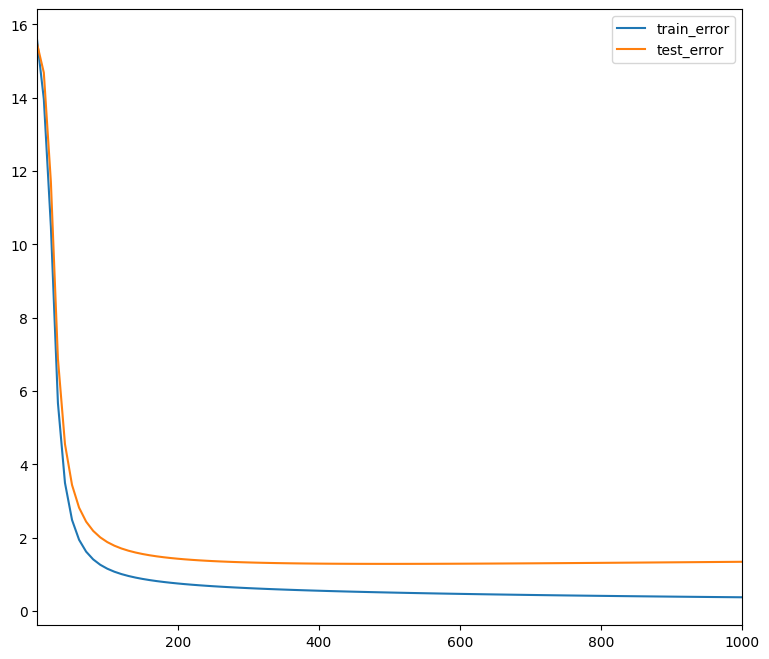

In [34]:
model = build_model(ratings, embedding_dim=30, init_stddev=0.5)
model.train(num_iterations=1000, learning_rate=10.)

In [35]:
DOT = 'dot'
COSINE = 'cosine'
def compute_scores(query_embedding, item_embeddings, measure=DOT):
 u = query_embedding
 V = item_embeddings
 if measure == COSINE:
  V = V / np.linalg.norm(V, axis=1, keepdims=True)
  u = u / np.linalg.norm(u)
 scores = u.dot(V.T)
 return scores

In [36]:
def user_recommendations(model, measure=DOT, exclude_rated=True, k=6):
 if USER_RATINGS:
  scores = compute_scores(
    model.embeddings["user_id"][942], model.embeddings["movie_id"], measure)
  score_key = measure + ' score'
  df = pd.DataFrame({
    score_key: list(scores),
    'movie_id': movies['movie_id'],
    'titles': movies['title'],
    'genres': movies['all_genres'],
  })
  if exclude_rated:
   # Menghapus film yang sudah diberikan rating oleh user.
   rated_movies = ratings[ratings.user_id == "942"]["movie_id"].values
   df = df[df.movie_id.apply(lambda movie_id: movie_id not in rated_movies)]
  display.display(df.sort_values([score_key], ascending=False).head(k))

1. Menghitung skor kesamaan antara embedding pengguna dan embedding semua film.
2. Membuat DataFrame yang berisi skor kesamaan, ID film, judul film, dan genre film.
3. Menghapus film yang sudah diberi rating oleh pengguna (jika exclude_rated adalah True).
4. Mengurutkan DataFrame berdasarkan skor kesamaan dan menampilkan sejumlah rekomendasi teratas yang ditentukan oleh parameter k.

In [37]:
USER_RATINGS = True
user_recommendations(model, measure=COSINE, k=5)
user_recommendations(model, measure=DOT, k=5)

,cosine score,movie_id,titles,genres
146,0.671,146,"Long Kiss Goodnight, The (1996)",Action-Thriller
409,0.667,409,Kingpin (1996),Comedy
780,0.662,780,French Kiss (1995),Comedy-Romance
934,0.654,934,Paradise Road (1997),Drama-War
898,0.654,898,"Winter Guest, The (1997)",Drama


,dot score,movie_id,titles,genres
898,6.536,898,"Winter Guest, The (1997)",Drama
1021,6.460,1021,"Fast, Cheap & Out of Control (1997)",Documentary
921,6.380,921,Dead Man (1995),Western
901,6.148,901,"Big Lebowski, The (1998)",Comedy-Crime-Mystery-Thriller
972,6.080,972,Grateful Dead (1995),Documentary


membuat rekomendasi berdasarkan kemiripan genre dari masing-masing film

In [38]:
def movie_neighbors(model, title_substring, measure=DOT, k=6):
 # Mencari film berdasarkan judul yang dimasukkan.
 ids = movies[movies['title'].str.contains(title_substring)].index.values
 titles = movies.iloc[ids]['title'].values
 if len(titles) == 0:
  raise ValueError("Found no movies with title %s" % title_substring)
 print("Nearest neighbors of : %s." % titles[0])
 if len(titles) > 1:
  print("[Found more than one matching movie. Other candidates: {}]".format(
    ", ".join(titles[1:])))
 movie_id = ids[0]
 scores = compute_scores(
   model.embeddings["movie_id"][movie_id], model.embeddings["movie_id"],
   measure)
 score_key = measure + ' score'
 df = pd.DataFrame({
   score_key: list(scores),
   'titles': movies['title'],
   'genres': movies['all_genres']
 })
 display.display(df.sort_values([score_key], ascending=False).head(k))

In [39]:
movie_neighbors(model, "Star Wars", DOT)
movie_neighbors(model, "Star Wars", COSINE)

Nearest neighbors of : Star Wars (1977).


,dot score,titles,genres
49,7.180,Star Wars (1977),Action-Adventure-Romance-Sci-Fi-War
612,6.656,My Man Godfrey (1936),Comedy
180,6.636,Return of the Jedi (1983),Action-Adventure-Romance-Sci-Fi-War
171,6.528,"Empire Strikes Back, The (1980)",Action-Adventure-Drama-Romance-Sci-Fi-War
173,6.420,Raiders of the Lost Ark (1981),Action-Adventure
11,6.068,"Usual Suspects, The (1995)",Crime-Thriller


Nearest neighbors of : Star Wars (1977).


,cosine score,titles,genres
49,1.000,Star Wars (1977),Action-Adventure-Romance-Sci-Fi-War
180,0.943,Return of the Jedi (1983),Action-Adventure-Romance-Sci-Fi-War
171,0.934,"Empire Strikes Back, The (1980)",Action-Adventure-Drama-Romance-Sci-Fi-War
173,0.903,Raiders of the Lost Ark (1981),Action-Adventure
209,0.899,Indiana Jones and the Last Crusade (1989),Action-Adventure
0,0.896,Toy Story (1995),Animation-Children-Comedy
